# Data-initialized planar simulation at 60 hpf

This draft makes the first explicit bridge between the tracked killifish data and the planar cell simulation. It:

1. loads and preprocesses the same deep-cell tracks used by `cell_dynamics_v4.ipynb`;
2. recovers that notebook's late-window aggregation pole (`COM_final`);
3. selects the pole-facing hemisphere at the observed frame closest to 60 hpf;
4. maps that hemisphere with a Lambert azimuthal equal-area projection; and
5. initializes `PlanarSimulationEngine` at the projected cell positions.

This is an exploratory initialization, not a calibrated dynamical model. Initial polarity and mechanical parameters remain explicit placeholders. The source notebook and source data are read only.


In [1]:
# Paths and imports adapted from the first code cell of the source notebook.
from pathlib import Path
import copy
import sys

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree
import zarr

if not str(zarr.__version__).startswith("2."):
    raise RuntimeError(
        "This notebook must use the symmetry-env kernel (Zarr 2.x). "
        f"Current interpreter: {sys.executable}; zarr={zarr.__version__}. "
        "In VS Code, use the notebook kernel picker at upper right and select symmetry-env."
    )

SOURCE_NOTEBOOK = Path(
    "/Users/nick/Projects/repositories/killi-dynamics/analysis/nlammers/20260807/"
    "cell_dynamics_v4.ipynb"
)
KILLI_REPO = SOURCE_NOTEBOOK.parents[3]
CELL_FLOW_REPO = Path("/Users/nick/Projects/repositories/cell-flow-sims")
DATA_ROOT = Path("/Users/nick/Projects/data/killi_dynamics")

for repo in (KILLI_REPO, CELL_FLOW_REPO):
    if not repo.is_dir():
        raise FileNotFoundError(repo)
    if str(repo) not in sys.path:
        sys.path.insert(0, str(repo))

from src.data_io.track_io import _load_track_data
from src.tracking.track_processing import preprocess_tracks, smooth_tracks

from cell_sphere_sim.planar import PlanarParams, PlanarSimulationEngine
from cell_sphere_sim.state import StateTable

print(f"source notebook: {SOURCE_NOTEBOOK}")
print(f"killi repo:      {KILLI_REPO}")
print(f"simulation repo: {CELL_FLOW_REPO}")


source notebook: /Users/nick/Projects/repositories/killi-dynamics/analysis/nlammers/20260807/cell_dynamics_v4.ipynb
killi repo:      /Users/nick/Projects/repositories/killi-dynamics
simulation repo: /Users/nick/Projects/repositories/cell-flow-sims


## 1. Load and preprocess the tracked cells

This is the loading path from the source notebook, with unrelated downstream analysis omitted. It intentionally smooths before removing stationary tracks, matching the source analysis. On the current dataset the serial smoothing step takes about one minute.


In [2]:
# Dataset and acquisition calibration from cell_dynamics_v4.ipynb.
PROJECT_NAME = "20251019_BC1-NLS_52-96hpf_redux"
TRACKING_CONFIG = "default_tracking_config"
START_HPF = 52.0
TRES_S = 92.5
TRES_H = TRES_S / 3600.0
SCALE_VEC_ZYX = np.asarray([3.0, 0.85, 0.85])

all_cells_df, _ = _load_track_data(
    root=DATA_ROOT,
    project_name=PROJECT_NAME,
    tracking_config=TRACKING_CONFIG,
    prefer_smoothed=False,
    scale_vec=SCALE_VEC_ZYX,
    fluo_channel_to_use=0,
    prefer_flow=False,
)
sphere_df = pd.read_csv(
    DATA_ROOT / "tracking" / PROJECT_NAME / "sphere_fits.csv"
)

# track_class == 0 is the deep-cell population used by the source analysis.
deep_tracks_df = all_cells_df.loc[all_cells_df["track_class"] == 0].copy()

SG_WINDOW_MINUTES = 10.0
SG_POLY = 2
sg_frames = int(SG_WINDOW_MINUTES / (TRES_S / 60.0))
sg_frames += 1 - sg_frames % 2
if sg_frames <= SG_POLY + 1:
    raise ValueError("Smoothing window is too short for the polynomial order.")
print(f"position smoothing: {sg_frames} frames = {sg_frames * TRES_S / 60:.1f} min")

deep_tracks_df = smooth_tracks(
    deep_tracks_df,
    dT=TRES_S / 60.0,
    sg_window_minutes=SG_WINDOW_MINUTES,
    sg_poly=SG_POLY,
    n_workers=1,
)
deep_tracks_df = preprocess_tracks(deep_tracks_df)
deep_tracks_df = deep_tracks_df.loc[
    ~deep_tracks_df["track_mostly_stationary"]
].copy()
deep_tracks_df["hpf"] = deep_tracks_df["t"] * TRES_H + START_HPF


position smoothing: 7 frames = 10.8 min


Smoothing tracks (serial): 100%|██████████| 69353/69353 [01:06<00:00, 1043.21track/s]


In [3]:
print(f"loaded rows:        {len(all_cells_df):,}")
print(f"usable deep rows:   {len(deep_tracks_df):,}")
print(f"deep-cell tracks:   {deep_tracks_df['track_id'].nunique():,}")
print(f"observed frames:    {deep_tracks_df['t'].nunique():,}")
print(
    f"developmental time: {deep_tracks_df['hpf'].min():.3f}-"
    f"{deep_tracks_df['hpf'].max():.3f} hpf"
)


loaded rows:        2,657,092
usable deep rows:   1,866,473
deep-cell tracks:   67,210
observed frames:    1,600
developmental time: 52.000-93.085 hpf


## 2. Sphere-relative coordinates and the aggregation pole

Each cell is converted to a unit direction from the fitted sphere center at its frame. Following the later hemisphere section of the source notebook, the relevant aggregation pole is the normalized mean direction over the **last two hours**, not the all-time COM. The all-time value is retained only as a diagnostic.


In [4]:
SPHERE_COLUMNS = [
    "center_x_smooth",
    "center_y_smooth",
    "center_z_smooth",
    "radius_smooth",
]
sphere_lookup = sphere_df[["t", *SPHERE_COLUMNS]].drop_duplicates("t")
if sphere_lookup["t"].duplicated().any():
    raise ValueError("Sphere fits must contain one row per frame.")

center_by_row = deep_tracks_df[["t"]].merge(
    sphere_lookup,
    on="t",
    how="left",
    validate="many_to_one",
)
if center_by_row[SPHERE_COLUMNS].isna().any().any():
    raise ValueError("Some track rows do not have a time-matched sphere fit.")

xyz = deep_tracks_df[["x", "y", "z"]].to_numpy(dtype=float)
center_xyz = center_by_row[
    ["center_x_smooth", "center_y_smooth", "center_z_smooth"]
].to_numpy(dtype=float)
unit_xyz = xyz - center_xyz
unit_norm = np.linalg.norm(unit_xyz, axis=1, keepdims=True)
if np.any(unit_norm <= 1e-12):
    raise ValueError("At least one cell lies at its fitted sphere center.")
unit_xyz /= unit_norm
deep_tracks_df[["xu", "yu", "zu"]] = unit_xyz

COM_all = deep_tracks_df[["xu", "yu", "zu"]].mean().to_numpy(dtype=float)
COM_all /= np.linalg.norm(COM_all)

AGG_WINDOW_HPF = 2.0
late_rows = deep_tracks_df["hpf"] >= deep_tracks_df["hpf"].max() - AGG_WINDOW_HPF
com_raw = deep_tracks_df.loc[late_rows, ["xu", "yu", "zu"]].mean().to_numpy(dtype=float)
COM_final = com_raw / np.linalg.norm(com_raw)

separation_deg = np.degrees(
    np.arccos(np.clip(COM_final @ COM_all, -1.0, 1.0))
)
print(f"late-window aggregation pole: {COM_final.round(6)}")
print(f"late-window resultant length: {np.linalg.norm(com_raw):.3f}")
print(f"difference from all-time COM: {separation_deg:.2f} degrees")


late-window aggregation pole: [0.736797 0.320583 0.595278]
late-window resultant length: 0.484
difference from all-time COM: 6.23 degrees


## 3. Project the aggregate-facing hemisphere

The exploratory choice here is a **Lambert azimuthal equal-area projection** centered on `COM_final`. For a unit sphere and angular distance $\theta$ from the pole, the projected radius is

$$r = 2\sin(\theta/2).$$

Multiplication by the fitted sphere radius preserves physical surface area. The pole remains at the origin, the aggregate-facing hemisphere maps one-to-one onto a disk of radius $\sqrt{2}R$, and the inverse map is retained below.

The disk is translated into a padded square **without stretching it to fill the square**. This leaves unused corners but avoids extra shape and density distortion. The planar engine is periodic, whereas a hemisphere has a circular rim; padding keeps the observed cells away from the periodic boundary initially, but that boundary mismatch remains an explicit limitation of longer runs.


In [5]:
def tangent_frame(pole):
    """Return an orthonormal basis whose third axis is the supplied pole."""
    pole = np.asarray(pole, dtype=float)
    pole = pole / np.linalg.norm(pole)
    seed = (
        np.array([0.0, 0.0, 1.0])
        if abs(pole[2]) < 0.9
        else np.array([1.0, 0.0, 0.0])
    )
    e1 = np.cross(seed, pole)
    e1 /= np.linalg.norm(e1)
    e2 = np.cross(pole, e1)
    return e1, e2


def project_lambert(unit_xyz, sphere_radius, pole, e1, e2):
    """Lambert azimuthal equal-area coordinates about `pole`."""
    unit_xyz = np.atleast_2d(np.asarray(unit_xyz, dtype=float))
    a = unit_xyz @ e1
    b = unit_xyz @ e2
    c = np.clip(unit_xyz @ pole, -1.0, 1.0)
    horizontal = np.hypot(a, b)
    radius_unit = np.sqrt(2.0 * (1.0 - c))
    scale = np.divide(
        radius_unit,
        horizontal,
        out=np.zeros_like(radius_unit),
        where=horizontal > 1e-12,
    )
    xy = sphere_radius * np.column_stack((a * scale, b * scale))
    angle_deg = np.degrees(np.arccos(c))
    return xy, angle_deg


def inverse_lambert(xy, sphere_radius, pole, e1, e2):
    """Invert the projection for points inside its radius-2 disk."""
    xy = np.atleast_2d(np.asarray(xy, dtype=float))
    uv = xy / sphere_radius
    radius_sq = np.sum(uv**2, axis=1)
    if np.any(radius_sq > 4.0 + 1e-10):
        raise ValueError("Lambert coordinates lie outside the full-sphere disk.")
    tangent_scale = np.sqrt(np.clip(1.0 - radius_sq / 4.0, 0.0, None))
    a = uv[:, 0] * tangent_scale
    b = uv[:, 1] * tangent_scale
    c = 1.0 - radius_sq / 2.0
    restored = a[:, None] * e1 + b[:, None] * e2 + c[:, None] * pole
    restored /= np.linalg.norm(restored, axis=1, keepdims=True)
    return restored


E1, E2 = tangent_frame(COM_final)


In [17]:
TARGET_HPF = 80
frame_times = deep_tracks_df.groupby("t", as_index=False)["hpf"].first()
target_row = frame_times.iloc[(frame_times["hpf"] - TARGET_HPF).abs().argmin()]
TARGET_FRAME = int(target_row["t"])
OBSERVED_HPF = float(target_row["hpf"])

frame_cells = deep_tracks_df.loc[deep_tracks_df["t"] == TARGET_FRAME].copy()
frame_unit = frame_cells[["xu", "yu", "zu"]].to_numpy(dtype=float)
pole_dot = frame_unit @ COM_final
hemisphere_mask = pole_dot >= 0.0
hemisphere_cells = frame_cells.loc[hemisphere_mask].copy().reset_index(drop=True)
hemisphere_unit = frame_unit[hemisphere_mask]

radius_rows = sphere_lookup.loc[
    sphere_lookup["t"] == TARGET_FRAME, "radius_smooth"
]
if len(radius_rows) != 1:
    raise ValueError("Expected one fitted sphere radius at the target frame.")
SPHERE_RADIUS_UM = float(radius_rows.iloc[0])
projected_xy, angle_from_pole_deg = project_lambert(
    hemisphere_unit, SPHERE_RADIUS_UM, COM_final, E1, E2
)

# Confirm that no angular information was lost for the retained hemisphere.
restored_unit = inverse_lambert(projected_xy, SPHERE_RADIUS_UM, COM_final, E1, E2)
roundtrip_error = np.max(np.linalg.norm(restored_unit - hemisphere_unit, axis=1))
if roundtrip_error > 1e-10:
    raise AssertionError(f"Lambert round-trip error is {roundtrip_error:.3g}")

# Use the independently motivated global contact diameter. Keep the strict
# no-overlap radius as a diagnostic, but do not use it for the simulation.
# Data-derived positions remain unchanged, so initial contacts are retained.
CONTACT_DIAMETER_UM = 25.0
CELL_RADIUS_UM = 0.5 * CONTACT_DIAMETER_UM
nearest_neighbor_um = cKDTree(projected_xy).query(projected_xy, k=2)[0][:, 1]
MIN_NN_UM = float(np.min(nearest_neighbor_um[nearest_neighbor_um > 1e-9]))
SAFE_CELL_RADIUS_UM = 0.45 * MIN_NN_UM
INITIAL_CONTACT_PAIR_COUNT = len(
    cKDTree(projected_xy).query_pairs(CONTACT_DIAMETER_UM)
)
MAX_INITIAL_OVERLAP_UM = max(0.0, CONTACT_DIAMETER_UM - MIN_NN_UM)

HEMISPHERE_DISK_RADIUS_UM = np.sqrt(2.0) * SPHERE_RADIUS_UM
BOX_MARGIN_UM = max(10.0 * CELL_RADIUS_UM, 0.05 * HEMISPHERE_DISK_RADIUS_UM)
BOX_HALF_EXTENT_UM = HEMISPHERE_DISK_RADIUS_UM + BOX_MARGIN_UM
BOX_SIZE_UM = np.array([2.0 * BOX_HALF_EXTENT_UM] * 2)
simulation_xy = projected_xy + BOX_HALF_EXTENT_UM

initial_cells_df = hemisphere_cells[
    ["track_id", "parent_track_id", "x", "y", "z", "xu", "yu", "zu"]
].copy()
initial_cells_df["angle_from_aggregation_pole_deg"] = angle_from_pole_deg
initial_cells_df["projected_x_um"] = projected_xy[:, 0]
initial_cells_df["projected_y_um"] = projected_xy[:, 1]
initial_cells_df["simulation_x_um"] = simulation_xy[:, 0]
initial_cells_df["simulation_y_um"] = simulation_xy[:, 1]
initial_cells_df["nearest_neighbor_um"] = nearest_neighbor_um

print(f"requested time:          {TARGET_HPF:.3f} hpf")
print(f"selected frame:          {TARGET_FRAME} ({OBSERVED_HPF:.6f} hpf)")
print(f"deep cells in frame:     {len(frame_cells):,}")
print(f"pole-facing hemisphere:  {len(hemisphere_cells):,}")
print(f"fitted sphere radius:    {SPHERE_RADIUS_UM:.3f} um")
print(f"Lambert disk radius:     {HEMISPHERE_DISK_RADIUS_UM:.3f} um")
print(f"minimum projected NN:    {MIN_NN_UM:.3f} um")
print(f"configured cell radius:  {CELL_RADIUS_UM:9.3f} um")
print(f"contact diameter:        {CONTACT_DIAMETER_UM:9.3f} um")
print(f"strict no-overlap radius:{SAFE_CELL_RADIUS_UM:9.3f} um (diagnostic only)")
print(f"initial contact pairs:   {INITIAL_CONTACT_PAIR_COUNT:9,d}")
print(f"maximum initial overlap: {MAX_INITIAL_OVERLAP_UM:9.3f} um")
print(f"simulation box:          {BOX_SIZE_UM[0]:.3f} x {BOX_SIZE_UM[1]:.3f} um")
print(f"projection round-trip:   {roundtrip_error:.3e}")


requested time:          80.000 hpf
selected frame:          1090 (80.006944 hpf)
deep cells in frame:     1,495
pole-facing hemisphere:  1,145
fitted sphere radius:    509.349 um
Lambert disk radius:     720.328 um
minimum projected NN:    1.230 um
configured cell radius:     12.500 um
contact diameter:           25.000 um
strict no-overlap radius:    0.553 um (diagnostic only)
initial contact pairs:         886
maximum initial overlap:    23.770 um
simulation box:          1690.656 x 1690.656 um
projection round-trip:   4.571e-15


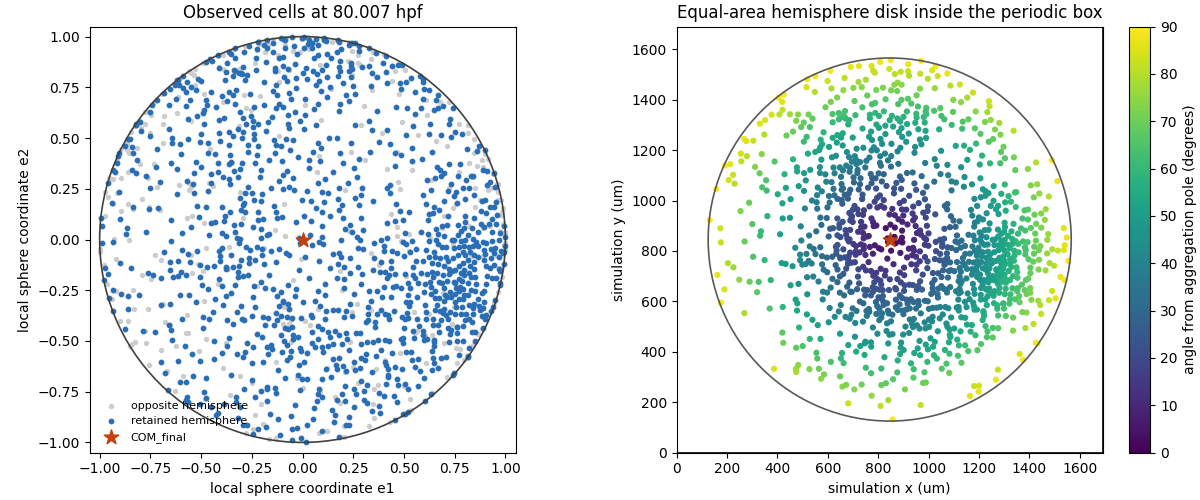

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Orthographic diagnostic: far-side points are shown but not retained.
local_a = frame_unit @ E1
local_b = frame_unit @ E2
axes[0].scatter(
    local_a[~hemisphere_mask], local_b[~hemisphere_mask],
    s=8, color="0.8", label="opposite hemisphere"
)
axes[0].scatter(
    local_a[hemisphere_mask], local_b[hemisphere_mask],
    s=10, color="#2a6fb5", label="retained hemisphere"
)
axes[0].add_patch(Circle((0, 0), 1.0, fill=False, color="0.25", lw=1.2))
axes[0].scatter([0], [0], marker="*", s=120, color="#c2410c", label="COM_final")
axes[0].set(
    aspect="equal", xlim=(-1.05, 1.05), ylim=(-1.05, 1.05),
    xlabel="local sphere coordinate e1", ylabel="local sphere coordinate e2",
    title=f"Observed cells at {OBSERVED_HPF:.3f} hpf",
)
axes[0].legend(frameon=False, fontsize=8, loc="lower left")

colour = angle_from_pole_deg
points = axes[1].scatter(
    simulation_xy[:, 0], simulation_xy[:, 1], c=colour,
    s=12, cmap="viridis", vmin=0, vmax=90
)
axes[1].add_patch(
    Circle(
        (BOX_HALF_EXTENT_UM, BOX_HALF_EXTENT_UM),
        HEMISPHERE_DISK_RADIUS_UM, fill=False, color="0.35", lw=1.2,
    )
)
axes[1].add_patch(
    Rectangle((0, 0), *BOX_SIZE_UM, fill=False, color="black", lw=1.2)
)
axes[1].scatter(
    [BOX_HALF_EXTENT_UM], [BOX_HALF_EXTENT_UM],
    marker="*", s=120, color="#c2410c",
)
axes[1].set(
    aspect="equal", xlim=(0, BOX_SIZE_UM[0]), ylim=(0, BOX_SIZE_UM[1]),
    xlabel="simulation x (um)", ylabel="simulation y (um)",
    title="Equal-area hemisphere disk inside the periodic box",
)
fig.colorbar(points, ax=axes[1], label="angle from aggregation pole (degrees)")
plt.show()


## 4. EM fit of free, flow-subtracted motion

This first-pass likelihood uses raw (unsmoothed) positions from 60–65 hpf. A point is called free only when its nearest other deep-cell center is farther than 40 µm, and both endpoints of a step must be free.

Before fitting, a local flow is estimated independently at every cell and frame. `scipy.spatial.cKDTree.query_ball_point` finds other velocity-bearing cells within 100 µm. Their tangent velocities are parallel-transported to the focal tangent plane and a leave-one-out, distance-weighted local constant velocity is fitted. The EM input is the residual after subtracting this local flow.

For residual tangent displacement $\Delta\mathbf{x}_k$, the working hidden-angle model is

$$\theta_{k+1}-\theta_k\sim\mathcal{N}_{\mathrm{wrapped}}(0,2D_r\Delta t),$$

$$\Delta\mathbf{x}_k\mid\theta_k\sim\mathcal{N}\left(v_0\Delta t\begin{bmatrix}\cos\theta_k\\\sin\theta_k\end{bmatrix},\sigma_{\mathrm{step}}^2I\right).$$

Only the discretized polarity angle is latent here. The fitted step noise absorbs localization error and model discrepancy, but this approximation ignores the negative correlation that localization error creates between consecutive displacements.


In [8]:
from cell_sphere_sim.inference import fit_free_motion_em

FIT_START_HPF = 60.0
FIT_END_HPF = 65.0
FREE_BUFFER_UM = 40.0
FLOW_RADIUS_UM = 100.0
FLOW_MIN_NEIGHBORS = 8
MIN_SEGMENT_STEPS = 8
EM_MAX_STEPS = 6000
EM_ANGLE_BINS = 48
EM_SEED = 20260814

# Return to the loader's unsmoothed coordinates. The valid-track set comes
# from the smoothing-based stationary filter above, but no smoothed position
# enters the likelihood.
valid_track_ids = set(deep_tracks_df["track_id"].unique())
raw_deep = all_cells_df.loc[all_cells_df["track_class"] == 0].copy()
raw_deep["hpf"] = raw_deep["t"] * TRES_H + START_HPF
raw_deep = raw_deep.loc[
    (raw_deep["hpf"] >= FIT_START_HPF)
    & (raw_deep["hpf"] <= FIT_END_HPF)
].copy()
raw_deep = raw_deep.merge(
    sphere_lookup, on="t", how="left", validate="many_to_one"
).reset_index(drop=True)
if raw_deep[SPHERE_COLUMNS].isna().any().any():
    raise ValueError("The EM window contains rows without a sphere fit.")

raw_xyz = raw_deep[["x", "y", "z"]].to_numpy(dtype=float)
raw_center = raw_deep[
    ["center_x_smooth", "center_y_smooth", "center_z_smooth"]
].to_numpy(dtype=float)
raw_normal = raw_xyz - raw_center
raw_normal /= np.clip(np.linalg.norm(raw_normal, axis=1, keepdims=True), 1e-12, None)
raw_deep[["nx", "ny", "nz"]] = raw_normal
raw_sphere_xyz = raw_normal * raw_deep["radius_smooth"].to_numpy(dtype=float)[:, None]
raw_deep[["sphere_x", "sphere_y", "sphere_z"]] = raw_sphere_xyz

# Conservative contact screen in the original spherical coordinates.
nearest_neighbor_um = np.full(len(raw_deep), np.nan)
for _, frame_group in raw_deep.groupby("t", sort=False):
    rows = frame_group.index.to_numpy()
    points = frame_group[["sphere_x", "sphere_y", "sphere_z"]].to_numpy(dtype=float)
    if len(rows) >= 2:
        nearest_neighbor_um[rows] = cKDTree(points).query(points, k=2)[0][:, 1]
raw_deep["nearest_neighbor_um"] = nearest_neighbor_um
raw_deep["free_point"] = raw_deep["nearest_neighbor_um"] > FREE_BUFFER_UM

print(f"raw deep-cell points in window: {len(raw_deep):,}")
print(f"frames: {raw_deep['t'].nunique():,}")
print(f"points beyond {FREE_BUFFER_UM:.0f} um: {raw_deep['free_point'].mean():.1%}")


raw deep-cell points in window: 163,322
frames: 194
points beyond 40 um: 40.2%


In [9]:
def rotate_tangent_vectors(vectors, normal_from, normal_to, eps=1e-12):
    """Minimal sphere rotation from `normal_from` to `normal_to`."""
    vectors = np.asarray(vectors, dtype=float)
    normal_from = np.asarray(normal_from, dtype=float)
    normal_to = np.broadcast_to(np.asarray(normal_to, dtype=float), normal_from.shape)
    axis = np.cross(normal_from, normal_to)
    sine = np.linalg.norm(axis, axis=1)
    cosine = np.clip(np.sum(normal_from * normal_to, axis=1), -1.0, 1.0)
    rotated = vectors.copy()
    mask = sine > eps
    if np.any(mask):
        unit_axis = axis[mask] / sine[mask, None]
        selected = vectors[mask]
        rotated[mask] = (
            selected * cosine[mask, None]
            + np.cross(unit_axis, selected) * sine[mask, None]
            + unit_axis
            * np.sum(unit_axis * selected, axis=1)[:, None]
            * (1.0 - cosine[mask, None])
        )
    rotated -= np.sum(rotated * normal_to, axis=1)[:, None] * normal_to
    return rotated


# Construct consecutive raw steps for every deep-cell track.
raw_deep = raw_deep.sort_values(["track_id", "t"]).reset_index(drop=True)
grouped = raw_deep.groupby("track_id", sort=False)
for column in [
    "t", "hpf", "nx", "ny", "nz", "radius_smooth", "free_point"
]:
    raw_deep[f"next_{column}"] = grouped[column].shift(-1)
consecutive = raw_deep["next_t"] == raw_deep["t"] + 1
steps = raw_deep.loc[consecutive].copy().reset_index(drop=True)

normal_start = steps[["nx", "ny", "nz"]].to_numpy(dtype=float)
normal_end = steps[["next_nx", "next_ny", "next_nz"]].to_numpy(dtype=float)
normal_dot = np.clip(np.sum(normal_start * normal_end, axis=1), -1.0, 1.0)
arc_angle = np.arccos(normal_dot)
tangent = normal_end - normal_dot[:, None] * normal_start
tangent_norm = np.linalg.norm(tangent, axis=1)
tangent_direction = np.divide(
    tangent, tangent_norm[:, None],
    out=np.zeros_like(tangent), where=tangent_norm[:, None] > 1e-12,
)
mean_radius = 0.5 * (
    steps["radius_smooth"].to_numpy(dtype=float)
    + steps["next_radius_smooth"].to_numpy(dtype=float)
)
observed_displacement_3d = mean_radius[:, None] * arc_angle[:, None] * tangent_direction
observed_velocity_3d = observed_displacement_3d / TRES_H
steps[["velocity_x", "velocity_y", "velocity_z"]] = observed_velocity_3d
steps["free_step"] = (
    steps["free_point"].astype(bool)
    & steps["next_free_point"].astype(bool)
)
steps["usable_track"] = steps["track_id"].isin(valid_track_ids)

# Leave-one-out local constant flow fit inside each 100 um ball. Neighbor
# velocities are parallel-transported before their weighted average.
local_flow_3d = np.full_like(observed_velocity_3d, np.nan)
flow_neighbor_count = np.zeros(len(steps), dtype=int)
for _, frame_group in steps.groupby("t", sort=False):
    rows = frame_group.index.to_numpy()
    positions = frame_group[["sphere_x", "sphere_y", "sphere_z"]].to_numpy(dtype=float)
    normals = frame_group[["nx", "ny", "nz"]].to_numpy(dtype=float)
    velocities = frame_group[["velocity_x", "velocity_y", "velocity_z"]].to_numpy(dtype=float)
    tree = cKDTree(positions)
    neighborhoods = tree.query_ball_point(positions, r=FLOW_RADIUS_UM)
    for local_index, neighbor_list in enumerate(neighborhoods):
        neighbors = np.asarray(
            [index for index in neighbor_list if index != local_index], dtype=int
        )
        flow_neighbor_count[rows[local_index]] = neighbors.size
        if neighbors.size < FLOW_MIN_NEIGHBORS:
            continue
        distance = np.linalg.norm(positions[neighbors] - positions[local_index], axis=1)
        weight = np.exp(-0.5 * (distance / FLOW_RADIUS_UM) ** 2)
        transported = rotate_tangent_vectors(
            velocities[neighbors], normals[neighbors], normals[local_index]
        )
        local_flow_3d[rows[local_index]] = np.average(
            transported, axis=0, weights=weight
        )

steps[["flow_x", "flow_y", "flow_z"]] = local_flow_3d
steps["flow_neighbor_count"] = flow_neighbor_count
residual_velocity_3d = observed_velocity_3d - local_flow_3d
steps[["residual_vx", "residual_vy", "residual_vz"]] = residual_velocity_3d
steps["observed_speed_um_h"] = np.linalg.norm(observed_velocity_3d, axis=1)
steps["flow_speed_um_h"] = np.linalg.norm(local_flow_3d, axis=1)
steps["residual_speed_um_h"] = np.linalg.norm(residual_velocity_3d, axis=1)
steps["angle_from_pole_deg"] = np.degrees(
    np.arccos(np.clip(normal_start @ COM_final, -1.0, 1.0))
)
steps["eligible"] = (
    steps["free_step"]
    & steps["usable_track"]
    & (steps["flow_neighbor_count"] >= FLOW_MIN_NEIGHBORS)
    & np.all(np.isfinite(residual_velocity_3d), axis=1)
)

eligible = steps.loc[steps["eligible"]]
print(f"consecutive raw steps: {len(steps):,}")
print(f"eligible free steps:   {len(eligible):,} ({len(eligible) / len(steps):.1%})")
print(
    f"local-flow neighbors: median {eligible['flow_neighbor_count'].median():.0f}, "
    f"range {eligible['flow_neighbor_count'].min()}-"
    f"{eligible['flow_neighbor_count'].max()}"
)
print(
    f"median speed observed/local flow/residual: "
    f"{eligible['observed_speed_um_h'].median():.2f} / "
    f"{eligible['flow_speed_um_h'].median():.2f} / "
    f"{eligible['residual_speed_um_h'].median():.2f} um/h"
)


consecutive raw steps: 158,080
eligible free steps:   19,899 (12.6%)
local-flow neighbors: median 9, range 8-21
median speed observed/local flow/residual: 108.84 / 36.67 / 102.39 um/h


In [10]:
def initial_tangent_basis(normal):
    seed = (
        np.array([0.0, 0.0, 1.0])
        if abs(normal[2]) < 0.9
        else np.array([1.0, 0.0, 0.0])
    )
    first = np.cross(seed, normal)
    first /= np.linalg.norm(first)
    second = np.cross(normal, first)
    return first, second


def segment_displacements_in_transport_frame(segment):
    normals = segment[["nx", "ny", "nz"]].to_numpy(dtype=float)
    residual = segment[["residual_vx", "residual_vy", "residual_vz"]].to_numpy(dtype=float)
    first, second = initial_tangent_basis(normals[0])
    components = np.empty((len(segment), 2), dtype=float)
    for index in range(len(segment)):
        if index:
            basis = rotate_tangent_vectors(
                np.vstack((first, second)),
                np.repeat(normals[index - 1][None, :], 2, axis=0),
                normals[index],
            )
            first, second = basis
        components[index] = [residual[index] @ first, residual[index] @ second]
    return components * TRES_H


# Split eligible runs whenever a track or frame-contiguous run breaks.
segment_records = []
for track_id_value, track_steps in eligible.groupby("track_id", sort=False):
    track_steps = track_steps.sort_values("t")
    run_id = track_steps["t"].diff().ne(1).cumsum()
    for _, run in track_steps.groupby(run_id, sort=False):
        if len(run) < MIN_SEGMENT_STEPS:
            continue
        segment_records.append(
            {
                "track_id": int(track_id_value),
                "start_hpf": float(run["hpf"].iloc[0]),
                "end_hpf": float(run["next_hpf"].iloc[-1]),
                "median_angle_from_pole_deg": float(run["angle_from_pole_deg"].median()),
                "displacement": segment_displacements_in_transport_frame(run),
            }
        )

def sample_segment_records(records, max_steps, seed):
    rng = np.random.default_rng(seed)
    order = rng.permutation(len(records))
    chosen = []
    n_steps = 0
    for index in order:
        record = records[index]
        if chosen and n_steps + len(record["displacement"]) > max_steps:
            continue
        chosen.append(record)
        n_steps += len(record["displacement"])
        if n_steps >= max_steps:
            break
    return chosen

em_records = sample_segment_records(segment_records, EM_MAX_STEPS, EM_SEED)
em_segments = [record["displacement"] for record in em_records]
print(
    f"free runs >= {MIN_SEGMENT_STEPS} steps: {len(segment_records):,} "
    f"({sum(len(record['displacement']) for record in segment_records):,} steps)"
)
print(
    f"deterministic EM sample: {len(em_segments):,} runs, "
    f"{sum(len(segment) for segment in em_segments):,} steps"
)


free runs >= 8 steps: 755 (10,492 steps)
deterministic EM sample: 437 runs, 5,997 steps


FreeMotionEMFit(speed=72.12997223173069, rotational_diffusion=4.422059125365246, step_sigma=1.848327549516032, log_likelihood=-25756.073482756092, n_iterations=30, converged=True, n_segments=437, n_steps=5997, n_angle_bins=48, log_likelihood_history=(-26701.63809561094, -26379.454712168455, -26233.084121017928, -26129.949700777746, -26052.28106189554, -25992.06073353661, -25944.826616122897, -25907.587054393083, -25878.11783964197, -25854.707290397542, -25836.031240825963, -25821.066417780083, -25809.02220011125, -25799.28661138727, -25791.384314584462, -25784.944574760983, -25779.67691487605, -25775.352667629304, -25771.79098083123, -25768.848161182974, -25766.40951476903, -25764.38309923304, -25762.6949086434, -25761.285115774426, -25760.105183231295, -25759.115580658636, -25758.284003296554, -25757.58395941311, -25756.99365817274, -25756.495124460544))
v0 = 72.130 um/h
Dr = 4.4221 1/h
step sigma = 1.848 um per coordinate
persistence time = 0.226 h
persistence length = 16.311 um


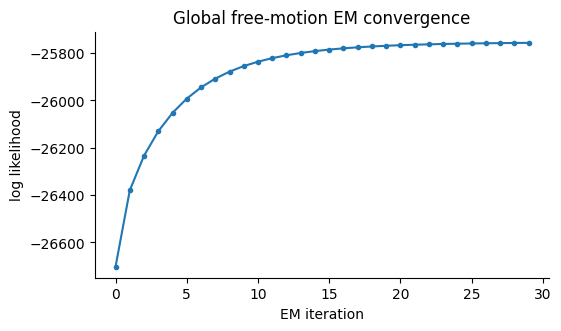

In [11]:
global_em_fit = fit_free_motion_em(
    em_segments,
    dt=TRES_H,
    n_angle_bins=EM_ANGLE_BINS,
    max_iterations=35,
    tolerance=2e-5,
)

persistence_time_h = 1.0 / global_em_fit.rotational_diffusion
persistence_length_um = global_em_fit.speed / global_em_fit.rotational_diffusion
print(global_em_fit)
print(f"v0 = {global_em_fit.speed:.3f} um/h")
print(f"Dr = {global_em_fit.rotational_diffusion:.4f} 1/h")
print(f"step sigma = {global_em_fit.step_sigma:.3f} um per coordinate")
print(f"persistence time = {persistence_time_h:.3f} h")
print(f"persistence length = {persistence_length_um:.3f} um")

fig, ax = plt.subplots(figsize=(5.5, 3.2), constrained_layout=True)
ax.plot(global_em_fit.log_likelihood_history, marker="o", ms=3)
ax.set(
    xlabel="EM iteration", ylabel="log likelihood",
    title="Global free-motion EM convergence",
)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
plt.show()


### Conditional fits for known subpopulations

As a concrete plug-in example, the cells are divided by whether the median position of their free run lies within 45° of the late aggregation pole. Each subgroup gets its own $v_0$ and $D_r$, while the global $\sigma_{\mathrm{step}}$ is held fixed. This conditions on a shared nuisance/noise model but does **not** yet provide hierarchical shrinkage or uncertainty in the global fit.


In [12]:
SUBPOPULATION_ANGLE_DEG = 45.0
conditional_rows = []
for label, keep in {
    "pole-proximal": lambda record: record["median_angle_from_pole_deg"] < SUBPOPULATION_ANGLE_DEG,
    "pole-distal": lambda record: record["median_angle_from_pole_deg"] >= SUBPOPULATION_ANGLE_DEG,
}.items():
    group_records = [record for record in segment_records if keep(record)]
    group_records = sample_segment_records(group_records, 3500, EM_SEED + len(conditional_rows) + 1)
    if sum(len(record["displacement"]) for record in group_records) < 100:
        continue
    group_fit = fit_free_motion_em(
        [record["displacement"] for record in group_records],
        dt=TRES_H,
        n_angle_bins=EM_ANGLE_BINS,
        max_iterations=35,
        tolerance=2e-5,
        initial_speed=global_em_fit.speed,
        initial_rotational_diffusion=global_em_fit.rotational_diffusion,
        fixed_step_sigma=global_em_fit.step_sigma,
    )
    conditional_rows.append(
        {
            "subpopulation": label,
            "n_segments": group_fit.n_segments,
            "n_steps": group_fit.n_steps,
            "speed_um_h": group_fit.speed,
            "Dr_per_h": group_fit.rotational_diffusion,
            "persistence_h": 1.0 / group_fit.rotational_diffusion,
            "converged": group_fit.converged,
        }
    )
conditional_fit_df = pd.DataFrame(conditional_rows)
conditional_fit_df


,subpopulation,n_segments,n_steps,speed_um_h,Dr_per_h,persistence_h,converged
0,pole-proximal,182,2592,74.125829,3.430061,0.291540,True
1,pole-distal,249,3498,71.950337,4.386457,0.227974,True


## 5. Initialize the planar simulation from the EM fit

Positions, lineage identifiers, free speed, and rotational diffusion are now data-linked. The global EM fit above supplies the default $v_0$ and $D_r$; the remaining choices are intentionally visible:

- cells default to state 0, with an editable track-ID selector that can flag any subset as state 1;
- polarity is isotropic with a fixed random seed, rather than inferred from observed motion;
- the cell radius is fixed at $12.5\,\mu\mathrm{m}$ (a $25\,\mu\mathrm{m}$ contact diameter) from separate analyses; observed initial contacts are retained without moving cells;
- time is measured in hours and distance in micrometres;
- $F_m=\gamma_s v_0$, while $k_{\mathrm{rep}}$ is chosen from the exploratory ratio $M=F_m/k_{\mathrm{rep}}=0.2$; the trajectories do not separately identify force and drag;
- the zero-adhesion CIL-dispersive start uses $B=f_{\mathrm{CIL}}\sigma/v_0=1$; and
- proliferation and adhesion are disabled by default, but both states have explicit parameter rows ready to edit.

The original `track_id` and `parent_track_id` values are passed into the simulation so later data/simulation comparisons can retain provenance. The engine may warn that the timestep is small relative to free motility; that choice is intentional here because the initial contact forces, not free motility, set the stricter transient scale.


### Click circular regions for state 1

Run the next cell, set the shared radius $R$ in micrometres, and **left-click** any number of disk centers. Cells inside the union of the red disks are assigned to state 1. **Undo last** and **Clear all** edit the selection; changing $R$ updates every disk. The aggregation pole is at $(0,0)$ in this projected view.

The selector updates `SUBSTATE_REGION_CENTERS_UM` and `SUBSTATE_REGION_RADIUS_UM` after every edit and displays copyable values beneath the controls. After selecting regions, run the initialization cell below. Restarting the live simulation preserves the current assignment; to change assignments, edit this plot and rerun initialization.


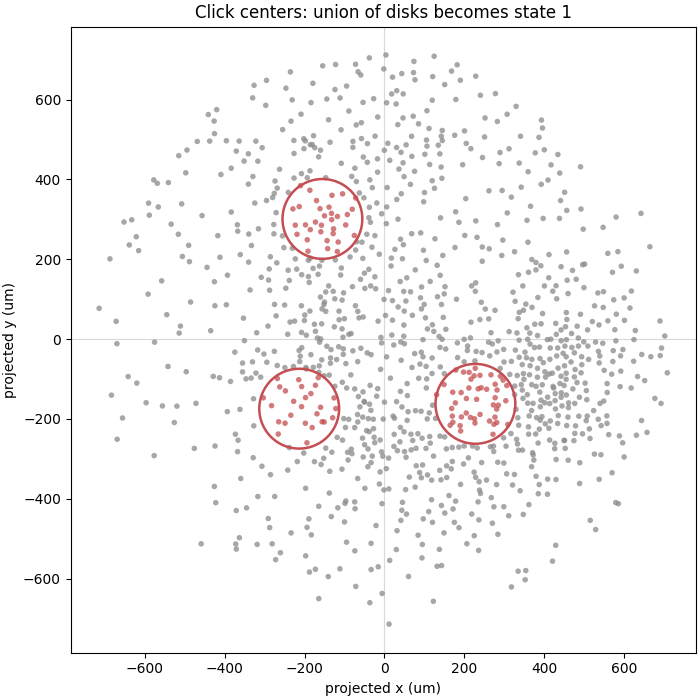

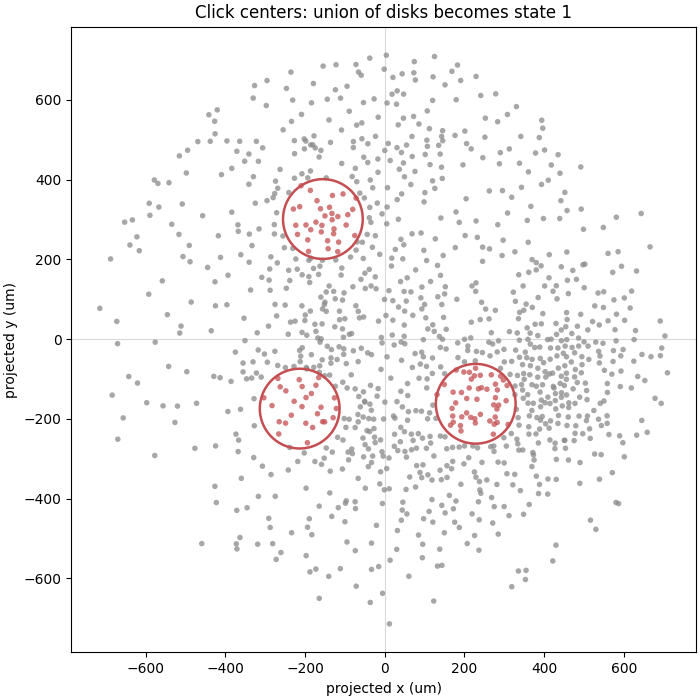

In [19]:
%matplotlib widget
from cell_sphere_sim.notebook_live import CircularRegionSelector

if "SUBSTATE_REGION_RADIUS_UM" not in globals():
    SUBSTATE_REGION_RADIUS_UM = 100.0
if "SUBSTATE_REGION_CENTERS_UM" not in globals():
    SUBSTATE_REGION_CENTERS_UM = np.empty((0, 2), dtype=float)

def store_substate_regions(centers, radius):
    global SUBSTATE_REGION_CENTERS_UM, SUBSTATE_REGION_RADIUS_UM
    SUBSTATE_REGION_CENTERS_UM = centers
    SUBSTATE_REGION_RADIUS_UM = radius

if "substate_region_selector" in globals():
    plt.close(substate_region_selector.figure)

substate_region_selector = CircularRegionSelector(
    initial_cells_df[["projected_x_um", "projected_y_um"]].to_numpy(),
    radius=SUBSTATE_REGION_RADIUS_UM,
    initial_centers=SUBSTATE_REGION_CENTERS_UM,
    on_change=store_substate_regions,
    title="Click centers: union of disks becomes state 1",
).show()


In [25]:
RNG_SEED = 20260814
GAMMA_S = 1.0
BASE_FREE_SPEED_UM_PER_H = float(global_em_fit.speed)
BASE_DR_PER_H = float(global_em_fit.rotational_diffusion)
MOTILITY_REPULSION_RATIO = 0.2  # M = Fm / K_REP
CIL_CROSSING_NUMBER = 1.0       # B = fcil * contact_diameter / speed
K_REP = GAMMA_S * BASE_FREE_SPEED_UM_PER_H / MOTILITY_REPULSION_RATIO
CONTACT_RELAXATION_STEP = 4e-4  # dt * K_REP / (gamma_s * contact diameter)
DT_H = (
    CONTACT_RELAXATION_STEP * GAMMA_S * CONTACT_DIAMETER_UM / K_REP
)

# State 0 is the baseline. State 1 is the union of explicitly listed track
# IDs and cells inside any clicked circular region. The fallbacks keep
# non-interactive/batch execution deterministic with no regions selected.
SUBSTATE_TRACK_IDS = set()
if "SUBSTATE_REGION_RADIUS_UM" not in globals():
    SUBSTATE_REGION_RADIUS_UM = 100.0
if "SUBSTATE_REGION_CENTERS_UM" not in globals():
    SUBSTATE_REGION_CENTERS_UM = np.empty((0, 2), dtype=float)

def select_substate(cells):
    track_mask = cells["track_id"].isin(SUBSTATE_TRACK_IDS).to_numpy(dtype=bool)
    centers = np.asarray(SUBSTATE_REGION_CENTERS_UM, dtype=float)
    if centers.size == 0:
        return track_mask
    centers = centers.reshape(-1, 2)
    points = cells[["projected_x_um", "projected_y_um"]].to_numpy(dtype=float)
    squared_distance = np.sum(
        (points[:, None, :] - centers[None, :, :]) ** 2, axis=2
    )
    region_mask = np.any(
        squared_distance <= float(SUBSTATE_REGION_RADIUS_UM) ** 2, axis=1
    )
    return track_mask | region_mask

# Each entry is [baseline state, flagged sub-state]. The two rows are
# deliberately identical until a sub-state-specific hypothesis is chosen.
STATE_RADIUS_UM = np.array([CELL_RADIUS_UM, CELL_RADIUS_UM])
STATE_FREE_SPEED_UM_PER_H = np.array([
    BASE_FREE_SPEED_UM_PER_H, BASE_FREE_SPEED_UM_PER_H
])
STATE_DR_PER_H = np.array([BASE_DR_PER_H, BASE_DR_PER_H])
STATE_FCIL_PER_H = (
    CIL_CROSSING_NUMBER * STATE_FREE_SPEED_UM_PER_H / (2.0 * STATE_RADIUS_UM)
)
STATE_ADHESION_RATIO = np.array([0.0, 0.0])  # w_s**2 / K_REP
STATE_DIVISION_RATE_PER_H = np.array([0.0, 0.0])
STATE_DIVISION_PAUSE_H = np.array([1.0, 1.0])

if np.any(STATE_ADHESION_RATIO < 0.0):
    raise ValueError("STATE_ADHESION_RATIO must be nonnegative.")
STATE_ADHESION_WEIGHT = np.sqrt(K_REP * STATE_ADHESION_RATIO)

n_cells = len(initial_cells_df)
substate_mask = np.asarray(select_substate(initial_cells_df), dtype=bool)
if substate_mask.shape != (n_cells,):
    raise ValueError("select_substate() must return one Boolean per cell.")
state_id = substate_mask.astype(np.int32)
state_vars = np.zeros((n_cells, 0), dtype=float)

# Polarity is deliberately not inferred yet. This keeps the positional data
# connection separate from the next modeling decision.
rng = np.random.default_rng(RNG_SEED)
polarity_angle = rng.uniform(0.0, 2.0 * np.pi, size=n_cells)
polarity = np.column_stack((np.cos(polarity_angle), np.sin(polarity_angle)))

track_id = pd.to_numeric(initial_cells_df["track_id"], errors="raise").to_numpy(
    dtype=np.int64
)
if np.unique(track_id).size != track_id.size:
    raise ValueError("Track IDs must be unique within the initialization frame.")
parent_numeric = pd.to_numeric(
    initial_cells_df["parent_track_id"], errors="coerce"
).to_numpy(dtype=float)
parent_id = np.where(np.isfinite(parent_numeric), parent_numeric, -1).astype(np.int64)

state_table = StateTable(
    R=STATE_RADIUS_UM,
    Fm=GAMMA_S * STATE_FREE_SPEED_UM_PER_H,
    Dr=STATE_DR_PER_H,
    fcil=STATE_FCIL_PER_H,
    w=STATE_ADHESION_WEIGHT,
    lambda_div=STATE_DIVISION_RATE_PER_H,
    tau_div=STATE_DIVISION_PAUSE_H,
)
params = PlanarParams(
    box_size=tuple(BOX_SIZE_UM),
    gamma_s=GAMMA_S,
    k_rep=K_REP,
    alpha_dmin=0.2,
    eps=1e-8,
    dt=DT_H,
    division_enabled=False,  # live controls can toggle this globally
    # Postpone births that cannot be inserted locally without a large jump.
    division_projection_failure_policy="reject",
    division_projection_max_displacement_factor=2.0,
)

engine = PlanarSimulationEngine(
    x=simulation_xy,
    p=polarity,
    state_id=state_id,
    state_vars=state_vars,
    state_table=state_table,
    params=params,
    rng=rng,
    track_id=track_id,
    parent_id=parent_id,
)

if not np.allclose(engine.x, simulation_xy):
    raise AssertionError("Engine initialization changed the projected positions.")
initial_cells_df["substate_flag"] = substate_mask
initial_cells_df["state_id"] = engine.state_id
initial_cells_df["p_x"] = engine.p[:, 0]
initial_cells_df["p_y"] = engine.p[:, 1]

print(f"initialized {engine.x.shape[0]:,} cells")
print(f"position match: {np.max(np.abs(engine.x - simulation_xy)):.3e} um max error")
print("state counts:   " + ", ".join(
    f"state {s} = {np.count_nonzero(engine.state_id == s):,}" for s in range(2)
))
print(
    f"state-1 regions: {len(np.asarray(SUBSTATE_REGION_CENTERS_UM).reshape(-1, 2))} "
    f"disk(s), R={SUBSTATE_REGION_RADIUS_UM:.3f} um"
)
print(f"free speeds:    {STATE_FREE_SPEED_UM_PER_H.tolist()} um/h")
print(f"motility ratio: {MOTILITY_REPULSION_RATIO:.3f}")
print(f"CIL crossing B: {CIL_CROSSING_NUMBER:.3f}")
print(f"adhesion ratio: {STATE_ADHESION_RATIO.tolist()}")
print(f"rotational Dr:  {STATE_DR_PER_H.tolist()} 1/h")
print(f"CIL rates:      {STATE_FCIL_PER_H.tolist()} 1/h")
print(f"time step:      {DT_H:.7f} h ({DT_H * 3600:.3f} s)")
print(f"division:       {engine.params.division_enabled}")


initialized 1,145 cells
position match: 0.000e+00 um max error
state counts:   state 0 = 735, state 1 = 410
state-1 regions: 10 disk(s), R=100.000 um
free speeds:    [72.12997223173069, 72.12997223173069] um/h
motility ratio: 0.200
CIL crossing B: 1.000
adhesion ratio: [0.0, 0.0]
rotational Dr:  [4.422059125365246, 4.422059125365246] 1/h
CIL rates:      [2.8851988892692275, 2.8851988892692275] 1/h
time step:      0.0000277 h (0.100 s)
division:       False


/Users/nick/Projects/repositories/cell-flow-sims/cell_sphere_sim/planar/engine.py:69: RuntimeWarning: dt may be too small for efficiency
  warnings.warn("dt may be too small for efficiency", RuntimeWarning)


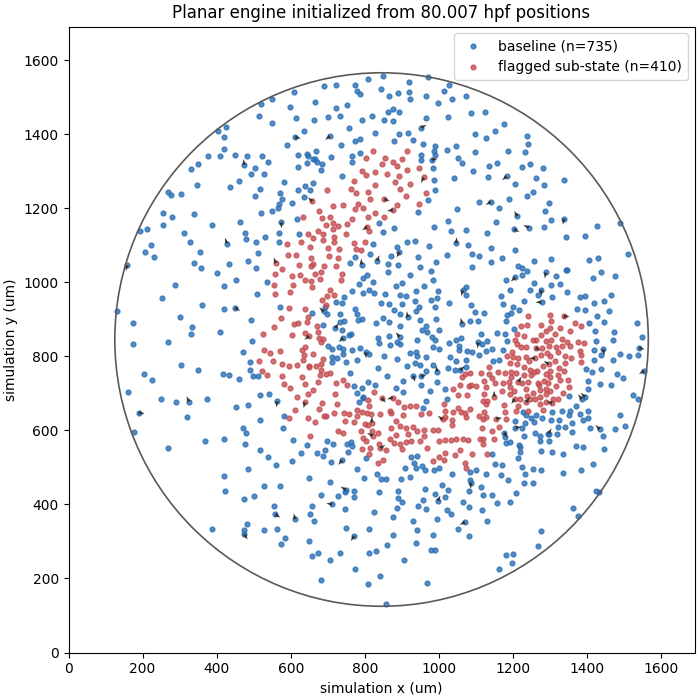

one-step smoke diagnostics: {'n_cells': 1145, 'mean_speed': 128203394077192.0, 'mean_contacts': 1.5475982532751091, 'n_candidates': 1118, 'n_contact_pairs': 886, 'min_d_contact': 1.2299953659218699, 'polarization': 0.04056996877782638, 'nematic_order': 0.029425700164740984, 'largest_cluster_fraction': 0.17903930131004367, 'mean_squared_displacement': 2.1517137650946262e+21, 'n_divisions': 0, 'n_division_attempts': 0, 'n_rejected_divisions': 0, 'total_divisions': 0, 'total_rejected_divisions': 0, 'division_projection_iterations': 0, 'division_projection_cells_moved': 0, 'division_projection_initial_overlap': 0.0, 'division_projection_residual_overlap': 0.0, 'division_projection_max_displacement': 0.0, 'division_projection_rms_displacement': 0.0}
maximum one-step displacement: 774709412470.2167 um


In [26]:
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
state_style = {0: ("baseline", "#2a6fb5"), 1: ("flagged sub-state", "#c44e52")}
for current_state, (label, color) in state_style.items():
    mask = engine.state_id == current_state
    if np.any(mask):
        ax.scatter(
            engine.x[mask, 0], engine.x[mask, 1],
            s=12, color=color, alpha=0.8, label=f"{label} (n={mask.sum():,})",
        )
stride = max(1, engine.x.shape[0] // 80)
ax.quiver(
    engine.x[::stride, 0], engine.x[::stride, 1],
    engine.p[::stride, 0], engine.p[::stride, 1],
    angles="xy", scale_units="xy", scale=0.06, width=0.0025, color="0.2",
)
ax.add_patch(
    Circle(
        (BOX_HALF_EXTENT_UM, BOX_HALF_EXTENT_UM),
        HEMISPHERE_DISK_RADIUS_UM, fill=False, color="0.35", lw=1.2,
    )
)
ax.set(
    aspect="equal", xlim=(0, BOX_SIZE_UM[0]), ylim=(0, BOX_SIZE_UM[1]),
    xlabel="simulation x (um)", ylabel="simulation y (um)",
    title=f"Planar engine initialized from {OBSERVED_HPF:.3f} hpf positions",
)
ax.legend(loc="upper right")
plt.show()

# Run one step on a copy so the `engine` object above remains at the exact
# observed initialization while still exercising the simulation path.
trial_engine = copy.deepcopy(engine)
trial_diagnostics = trial_engine.step(t=0.0)
trial_displacement_um = np.linalg.norm(trial_engine.x_unwrapped - engine.x_unwrapped, axis=1)
print("one-step smoke diagnostics:", trial_diagnostics)
print(f"maximum one-step displacement: {trial_displacement_um.max():.4f} um")


## 6. Live simulation controls

The simulation can run directly inside the notebook without launching a separate GUI. The rendered PNG is updated asynchronously, so the kernel remains available for the **Start**, **Pause**, **Step once**, **Apply parameters**, **Restart**, and **Save snapshot** controls. Restart restores the exact 60 hpf positions, initial polarities, state labels, lineage identifiers, and random-number state, then applies the currently displayed parameters.

The global division checkbox enables or disables proliferation. The `division /h` and post-division `pause (h)` values are independently editable for each state; daughters inherit the parent's state. The saved-snapshot panel appends ordinary static figures to the notebook when requested.

> The dashed circle shows the initial hemisphere footprint. It is not a wall: dynamics remain periodic in the surrounding square. Populate `SUBSTATE_TRACK_IDS` above and rerun the initialization cells to make the second parameter row active.


In [28]:
from cell_sphere_sim.notebook_live import LivePlanarSimulation

live_sim = LivePlanarSimulation(
    engine,
    disk_center=(BOX_HALF_EXTENT_UM, BOX_HALF_EXTENT_UM),
    disk_radius=HEMISPHERE_DISK_RADIUS_UM,
    state_names=("baseline", "flagged sub-state"),
    steps_per_frame=20,
    frame_interval_s=0.15,
    max_cells=5000,
).show()


## Next data/simulation links

The initialization is now explicit and auditable. Useful next increments are:

1. infer initial planar polarity from short observed track histories around 60 hpf;
2. audit sensitivity around the independently selected $25\,\mu\mathrm{m}$ contact diameter;
3. refine the provisional EM likelihood and use contact-rich trajectories to constrain CIL, adhesion, and drag/force ratios;
4. compare projected observed displacement fields with simulated displacement fields over a short horizon; and
5. retain the current circular hemisphere footprint inside the periodic square while developing short-horizon comparisons. The circle is the initial data support, not a confining wall.
